### Active Accounts

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
## Importing the Active Accounts excel dataset and also printing the first 5 rows
Active_Acc = pd.read_csv("../Datasets/Active_Accounts.csv", thousands=",") # thousands tells pandas , is only a separator inside numbers not text
Active_Acc.head()

,Date,Northern Africa,Eastern Africa,Middle Africa,Southern Africa,Western Africa
0,12/11/2026,4015,13558273,3982,29179,407426
1,03/12/2026,4595,14958487,8761,35311,532486
2,06/12/2026,37370,17455186,16123,43996,646257
3,09/12/2026,54780,18631344,105187,76719,852027
4,12/12/2026,70920,20965249,138939,160945,1315970


In [26]:
#Converting all columns names to lowercase
Active_Acc.columns = Active_Acc.columns.str.lower()

# Remove leading/trailing spaces and replace internal spaces with underscores
Active_Acc.columns = Active_Acc.columns.str.strip().str.replace(' ', '_')

print(Active_Acc.columns.tolist())

['date', 'northern_africa', 'eastern_africa', 'middle_africa', 'southern_africa', 'western_africa']


In [27]:
Active_Acc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             53 non-null     object
 1   northern_africa  53 non-null     int64 
 2   eastern_africa   53 non-null     int64 
 3   middle_africa    53 non-null     int64 
 4   southern_africa  53 non-null     int64 
 5   western_africa   53 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 2.6+ KB


In [28]:
Active_Acc.isnull().sum()

date               0
northern_africa    0
eastern_africa     0
middle_africa      0
southern_africa    0
western_africa     0
dtype: int64

In [29]:
# Display statistical summary of all the numerical columns transposed
Active_Acc.describe().T

,count,mean,std,min,25%,50%,75%,max
northern_africa,53.0,9.913190e+05,7.951486e+05,4015.0,413409.0,969876.0,1110076.0,3423588.0
eastern_africa,53.0,7.115625e+07,3.967067e+07,13558273.0,36327225.0,66295294.0,103031077.0,149409493.0
middle_africa,53.0,1.157837e+07,1.022086e+07,3982.0,2798550.0,8750738.0,20387308.0,32122117.0
southern_africa,53.0,2.027677e+06,1.536960e+06,29179.0,786089.0,1539871.0,3483928.0,4985801.0
western_africa,53.0,3.422953e+07,2.949966e+07,407426.0,7503847.0,27515219.0,54623256.0,97335540.0


In [31]:
# Converting Clean date from object to date.
Active_Acc["date"] = pd.to_datetime(Active_Acc["date"])
Active_Acc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             53 non-null     datetime64[ns]
 1   northern_africa  53 non-null     int64         
 2   eastern_africa   53 non-null     int64         
 3   middle_africa    53 non-null     int64         
 4   southern_africa  53 non-null     int64         
 5   western_africa   53 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 2.6 KB


In [35]:
Active_Acc_Dec_raw = Active_Acc[Active_Acc["date"].dt.month == 12].copy()

In [36]:
# Extracting the year from the clean date column
# (Errors='coerce' handles any messy strings safely)
Active_Acc_Dec_raw["Year"] = pd.to_datetime(Active_Acc_Dec_raw["date"]).dt.year

In [37]:
Active_Acc_Dec = Active_Acc_Dec_raw.melt(
    id_vars=["date"], # date is preserved
    value_vars=[
        "northern_africa",
        "eastern_africa",
        "middle_africa",
        "southern_africa",
        "western_africa"  
    ],
    var_name="Region",
    value_name="Value"
)

In [38]:
Active_Acc_Dec["Value"] = pd.to_numeric(Active_Acc_Dec["Value"])

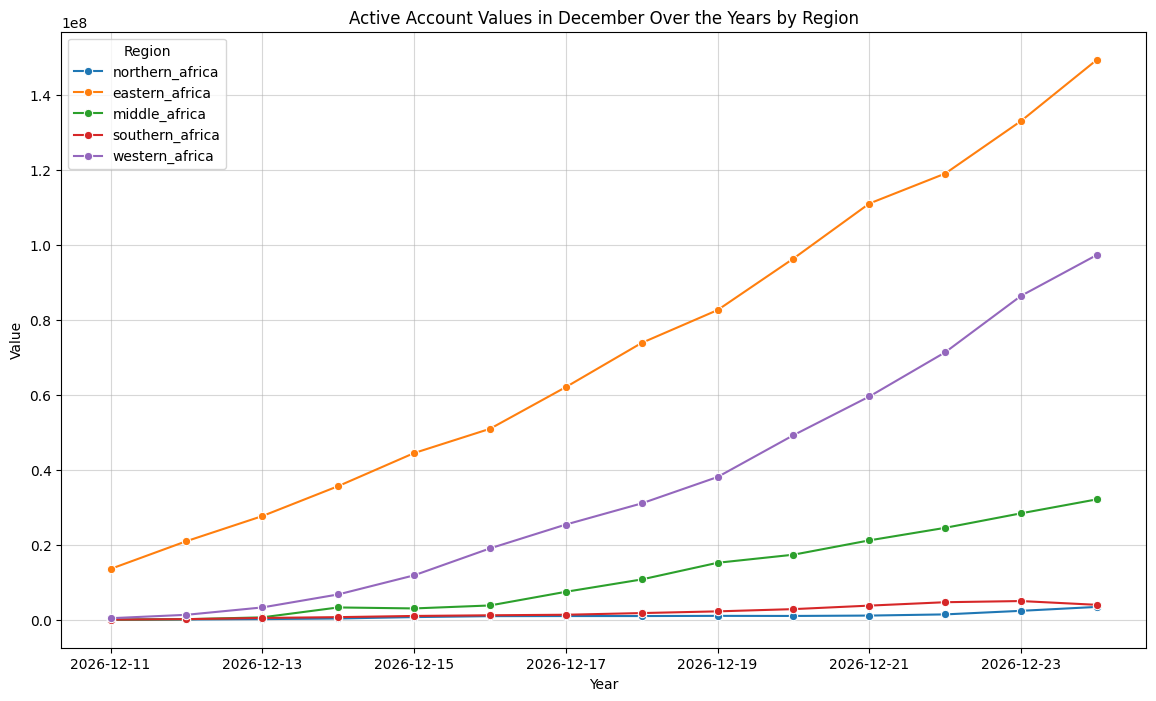

In [39]:
# 3. Plot using "date" as your X-axis
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=Active_Acc_Dec,
    x="date",          # Using 'date' directly since it represents the years
    y="Value",
    hue="Region",
    marker="o"
)

plt.title("Active Account Values in December Over the Years by Region")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True, linestyle="-", alpha=0.5)

plt.show()